# Exploratory data analysis of internet access

This notebook examines how internet access has evolved globally from 2000 to 2025, with a focus on the gap between income groups and world regions — and whether that gap is closing. I chose 2000 as it the point where data becomes more reliable as prior to 2000, data coverage of low-income countries is quite sparse.

## Data Source

- [Our World in Data – Share of the population using the Internet](https://ourworldindata.org/grapher/share-of-individuals-using-the-internet?country=WB_SA~WB_NA~WB_SSA~WB_EAP)

## Objectives

- How has global internet adoption evolved between 2000 and 2025?
- What are the internet adoption differences between socioeconomic groups?
- What are the internet adoption differences between regions?
- Is the adoption gap narrowing between regions and socioeconomic groups?
- What was the state of global internet adoption in 2025?


### Setup & Imports

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

In [75]:
data = pd.read_csv("../data/raw/share-of-individuals-using-the-internet.csv")

### Goals

#### 1. Global internet adoption trend — how has the share of people using the internet changed worldwide between 2000 and 2025?

In [76]:
data_2000_2025 = data[data['Year'] >= 2000]

In [77]:
world = data_2000_2025[data_2000_2025['Entity'] == 'World']

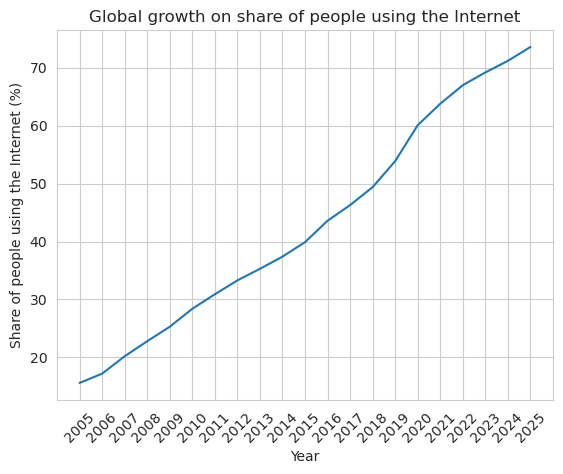

In [78]:
sns.lineplot(data=world, x='Year', y='Share of the population using the Internet')
plt.xlabel('Year')
plt.ylabel('Share of people using the Internet (%)')
plt.title('Global growth on share of people using the Internet')
plt.xticks(world['Year'].astype(int), rotation=45)
plt.savefig('../visualizations/global-growth.png', bbox_inches='tight')
plt.show()

Based on the line graph plot above, it is clear that global internet adoption has grown steadily over time. The World trend shows an increase in the share of people using the Internet grew by 58 percentage points, from ~15.6% in 2000 to ~73.6% in 2025. The line is roughly linear which means that there has been no significant change in the rate of growth over time around 2-3% every year.

#### 2. Internet adoption by socioeconomic group — how does adoption differ across income groups, and has the gap between them narrowed?

In [79]:
socioeconomic = data_2000_2025[data_2000_2025['Entity'].str.contains('income')]['Entity'].unique()
group_data = data_2000_2025[data_2000_2025['Entity'].isin(socioeconomic)]

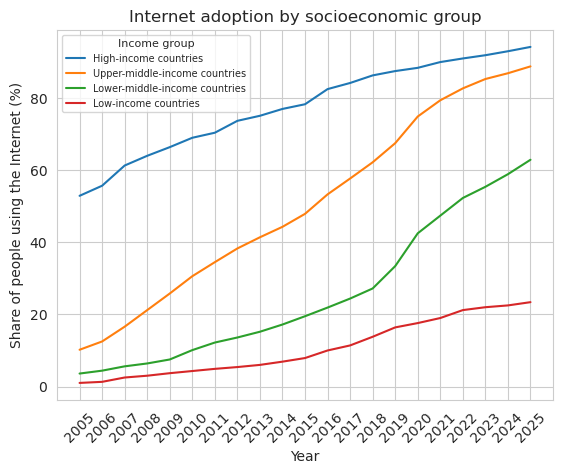

In [80]:
sns.lineplot(data=group_data, x='Year', y='Share of the population using the Internet', hue='Entity', hue_order=['High-income countries', 'Upper-middle-income countries', 'Lower-middle-income countries', 'Low-income countries']
)
plt.xlabel('Year')
plt.ylabel('Share of people using the Internet (%)')
plt.title('Internet adoption by socioeconomic group')
plt.xticks(world['Year'].astype(int), rotation=45)
plt.legend(title='Income group', fontsize=7, title_fontsize=8)
plt.savefig('../visualizations/internet-adoption-by-socioeconomic-group.png', bbox_inches='tight')
plt.show()

The gap between high-income and low-income countries in 2005 was 51.9 percentage points, low-income countries had 1% of share of people using the internet and high-income countries had 52.9% share of people using the internet. Two decades later the gap has increased to 70.8 percentage points, low-income countries have 23.4% of share of people using the internet and high-income countries have 94.2% share of people using the internet. Upper-middle-income countries adoption of internet grew the fastest. The gap between high-income countries and upper-middle-income countries is almost closed, but the gap between the other countries have increased, likely due to political instabilities, lack of accessible and affordable infrastructure for the general public or different governmental priorities.

#### 3. Internet adoption by region — how does adoption differ across world regions, and has the gap narrowed?

### Conclusion